In [1]:
from torchvision.io.image import read_image
from torchvision.utils import draw_bounding_boxes
from torchvision.transforms.functional import to_pil_image
from torchvision.models.detection import retinanet_resnet50_fpn_v2, RetinaNet_ResNet50_FPN_V2_Weights

import matplotlib.pyplot as plt

In [2]:
import requests
response = requests.get('https://i.ytimg.com/vi/q71MCWAEfL8/maxresdefault.jpg')
open("obj_det.jpeg", "wb").write(response.content)

img = read_image("obj_det.jpeg")

In [3]:
weights = RetinaNet_ResNet50_FPN_V2_Weights.DEFAULT
model = retinanet_resnet50_fpn_v2(weights=weights, score_thresh=0.35)
# Put the model in inference mode
model.eval()
# Get the transforms for the model's weights
preprocess = weights.transforms()

Downloading: "https://download.pytorch.org/models/retinanet_resnet50_fpn_v2_coco-5905b1c5.pth" to C:\Users\manue/.cache\torch\hub\checkpoints\retinanet_resnet50_fpn_v2_coco-5905b1c5.pth
100%|██████████| 146M/146M [00:11<00:00, 13.2MB/s] 


In [4]:
batch = [preprocess(img)]
prediction = model(batch)[0]

In [6]:
prediction

{'boxes': tensor([[ 564.5357,  308.0074,  723.3320,  429.9703],
         [  57.7738,  283.7292,  176.0529,  598.7919],
         [1033.5052,  339.5979, 1079.0691,  412.8081],
         [1088.8220,  318.2843, 1154.8586,  512.9001],
         [ 161.9359,  316.0273,  261.6374,  605.6806],
         [ 282.9404,  301.8982,  369.7855,  571.9400],
         [ 332.2874,  295.0135,  448.6103,  579.7318],
         [ 883.5612,  307.1185,  933.7031,  460.5947],
         [ 879.9528,  142.9108,  911.6091,  222.1381],
         [1009.6161,  311.6446, 1101.2513,  527.1226],
         [ 419.4928,  110.8182,  456.2020,  203.0418],
         [1022.8560,  325.1456, 1090.9934,  425.1520],
         [ 647.8596,  272.0102,  690.9261,  312.0713],
         [ 825.2953,  150.9667,  865.5046,  221.3485],
         [ 651.8381,  166.2852,  686.2664,  220.3865],
         [ 290.9169,  275.9924,  523.2353,  497.4279],
         [   2.0971,  304.8273,   81.7513,  599.1484],
         [1161.3848,  231.2964, 1280.0000,  509.9105],
 

c:\Users\manue\anaconda3\envs\ml\Lib\site-packages\torchvision\utils.py:225: UserWarning: Argument 'font_size' will be ignored since 'font' is not set.
  warnings.warn("Argument 'font_size' will be ignored since 'font' is not set.")


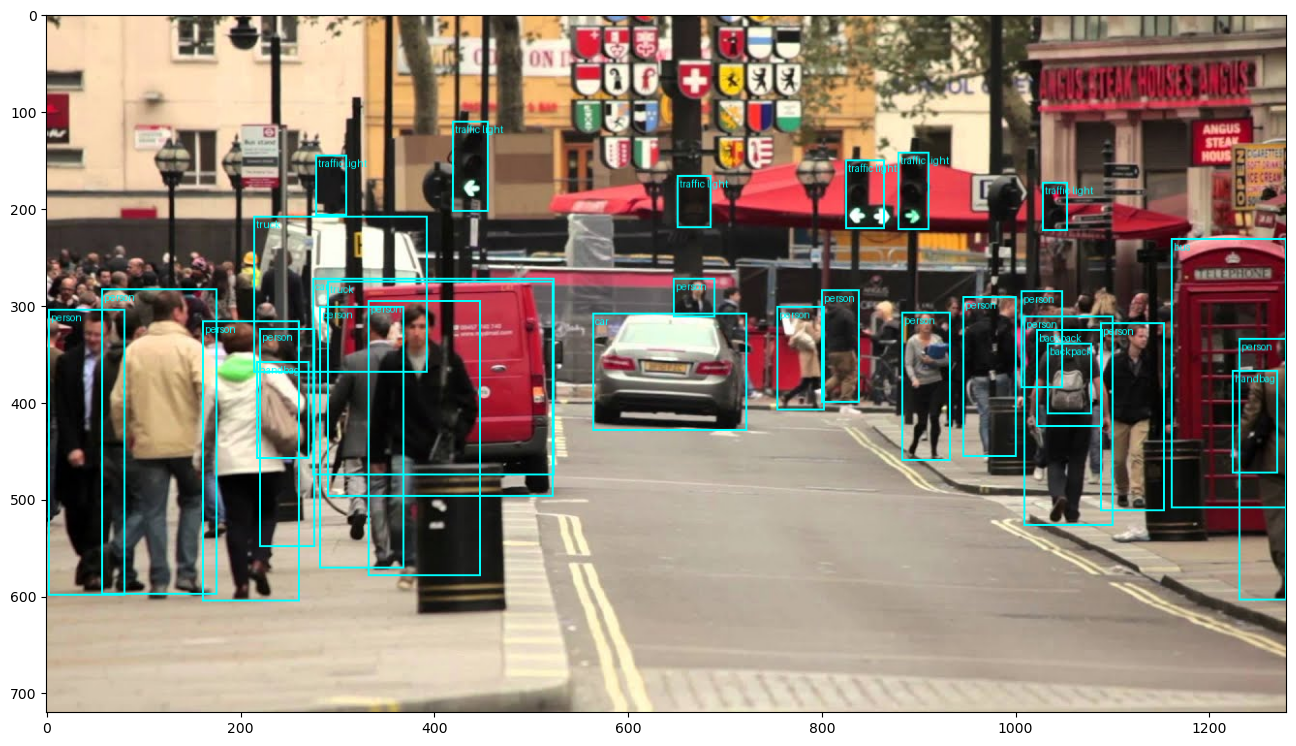

In [7]:
labels = [weights.meta["categories"][i] for i in prediction["labels"]]

box = draw_bounding_boxes(img, boxes=prediction["boxes"],
                          labels=labels,
                          colors="cyan",
                          width=2, 
                          font_size=30)

im = to_pil_image(box.detach())

fig, ax = plt.subplots(figsize=(16, 12))
ax.imshow(im)
plt.show()